In [1]:
import numpy as np
concept_sim = np.load('concept_sim.npy')
print(concept_sim.shape)

(40, 40)


C:\Users\Windows\AppData\Local\Temp\ipykernel_40780\792687078.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap)


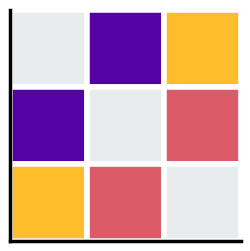

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_colored_matrix(values, cmap="viridis", diag_color="#E9ECEF"):
    """
    绘制 3x3 彩色矩阵，格子间有白线，对角线为浅灰色

    Args:
        values (np.ndarray): 3x3 数组，表示每个格子的数值
        cmap (str): matplotlib colormap 名称，例如 "viridis", "plasma", "coolwarm"
        diag_color (str): 主对角线颜色（默认浅灰色）
    """
    if values.shape != (3, 3):
        raise ValueError("Input must be a 3x3 matrix")

    # 归一化数值到 [0,1]
    norm = mcolors.Normalize(vmin=np.min(values), vmax=np.max(values))
    colormap = plt.cm.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)

    # 绘制矩阵
    for i in range(3):
        for j in range(3):
            if i == j:
                color = diag_color
            else:
                color = colormap(norm(values[i, j]))
            ax.add_patch(plt.Rectangle(
                (j, 2 - i), 1, 1, facecolor=color,
                edgecolor="white", linewidth=4
            ))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['bottom'].set_linewidth(2.5)
    plt.show()

# 示例数据
values = np.array([
    [1, 2, 7],
    [2, 6, 5],
    [7, 5, 8]
])

plot_colored_matrix(values, cmap="plasma")  # 可换成 "viridis", "coolwarm", "YlGnBu"


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_shared_semantic_space(n_points=12, seed=0):
    np.random.seed(seed)
    fig, ax = plt.subplots(figsize=(5, 5))

    # 定义三类语义簇的位置
    centers = np.array([[0, 0], [3, 3], [6, 0]])
    colors = ["#E74C3C", "#3498DB", "#2ECC71"]  # 红、蓝、绿

    markers = ["o", "^"]  # Subject A=圆, Subject B=三角
    labels = ["Subject A", "Subject B"]

    for k, (cx, cy) in enumerate(centers):
        for subj in range(2):
            # 在簇中心附近生成点
            pts = np.random.randn(n_points, 2) * 0.4 + np.array([cx, cy])
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=colors[k], marker=markers[subj], s=80,
                edgecolor="white", linewidth=0.8,
                label=f"{labels[subj]} ({'Class'+str(k+1)})" if k==0 else None
            )

    ax.set_title("Shared Semantic Representation Space", fontsize=14, pad=15)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-1, 7); ax.set_ylim(-2, 5)
    ax.set_aspect("equal")

    # 去掉边框，只留粗的左下
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)

    ax.legend(frameon=False, loc="upper right")
    plt.show()

plot_shared_semantic_space()
